In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
vis_dir = "visualizations" if os.path.exists("visualizations") else os.path.join("..", "visualizations")
model_dir = "model" if os.path.exists("model") else os.path.join("..", "model")
os.makedirs(vis_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

In [10]:
def load_split(filename):
    paths = [
        filename,
        os.path.join("data", filename),
        os.path.join("..", "data", filename)
    ]
    for p in paths:
        if os.path.exists(p):
            return pd.read_csv(p)
    raise FileNotFoundError(f"Could not find '{filename}'! Check data/ directory.")

X_test = load_split("X_test.csv")
y_test = load_split("y_test.csv").values.ravel()

# Fallback paths for loading model files
def load_model_file(filename, optional=False):
    paths = [
        os.path.join(model_dir, filename),
        filename
    ]
    for p in paths:
        if os.path.exists(p):
            return joblib.load(p)
    if optional:
        return None
    raise FileNotFoundError(f"Could not find '{filename}' in '{model_dir}' or the root directory.")

# Load saved pipeline and model with fallbacks
model = load_model_file("best_student_model.joblib")
preprocessor = load_model_file("preprocessor.joblib", optional=True)

print("✓ Testing environment initialized.")
print(f"  Test set shape: {X_test.shape}")
print(f"  Loaded model: {type(model).__name__}")
if preprocessor:
    print(f"  Loaded preprocessor: {type(preprocessor).__name__}")
else:
    print("  No external preprocessor loaded (assuming preprocessing is built into the model pipeline).")

✓ Testing environment initialized.
  Test set shape: (1322, 27)
  Loaded model: LinearRegression
  No external preprocessor loaded (assuming preprocessing is built into the model pipeline).


Stress-Testing Hypothetical Profiles (Students A, B, C)

In [13]:
# Since we do not have the fitted preprocessor object to scale and encode raw profile dictionaries,
# we will stress-test the model by grabbing actual preprocessed profiles directly from X_test.

# Identify indices of high, typical, and at-risk profiles based on actual labels (y_test)
high_idx = np.argmax(y_test)   # Highest score in test set
low_idx = np.argmin(y_test)    # Lowest score in test set
mid_idx = np.argsort(y_test)[len(y_test)//2]  # Median score in test set

# Extract the preprocessed feature vectors
student_A_features = X_test.iloc[[high_idx]]
student_B_features = X_test.iloc[[mid_idx]]
student_C_features = X_test.iloc[[low_idx]]

# Predict using model directly
def predict_preprocessed(features_df):
    pred_val = model.predict(features_df)[0]
    return round(float(np.clip(pred_val, 0, 100)), 2)

score_A = predict_preprocessed(student_A_features)
score_B = predict_preprocessed(student_B_features)
score_C = predict_preprocessed(student_C_features)

test_results_df = pd.DataFrame([
    {"Profile": "Student A (High-performing Sample)", "Actual Score": f"{y_test[high_idx]} marks", "Predicted Score": f"{score_A} marks"},
    {"Profile": "Student B (Median-performing Sample)", "Actual Score": f"{y_test[mid_idx]} marks", "Predicted Score": f"{score_B} marks"},
    {"Profile": "Student C (At-risk Sample)", "Actual Score": f"{y_test[low_idx]} marks", "Predicted Score": f"{score_C} marks"}
])

print("=" * 80)
print("             STRESS-TESTING RESULTS ON PREPROCESSED PROFILES")
print("=" * 80)
display(test_results_df)

             STRESS-TESTING RESULTS ON PREPROCESSED PROFILES


,Profile,Actual Score,Predicted Score
0,Student A (High-performing Sample),98 marks,70.9 marks
1,Student B (Median-performing Sample),67 marks,67.1 marks
2,Student C (At-risk Sample),55 marks,55.38 marks


/tmp/ipykernel_893/3612791788.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, y="Feature", x="Importance", palette=colors)


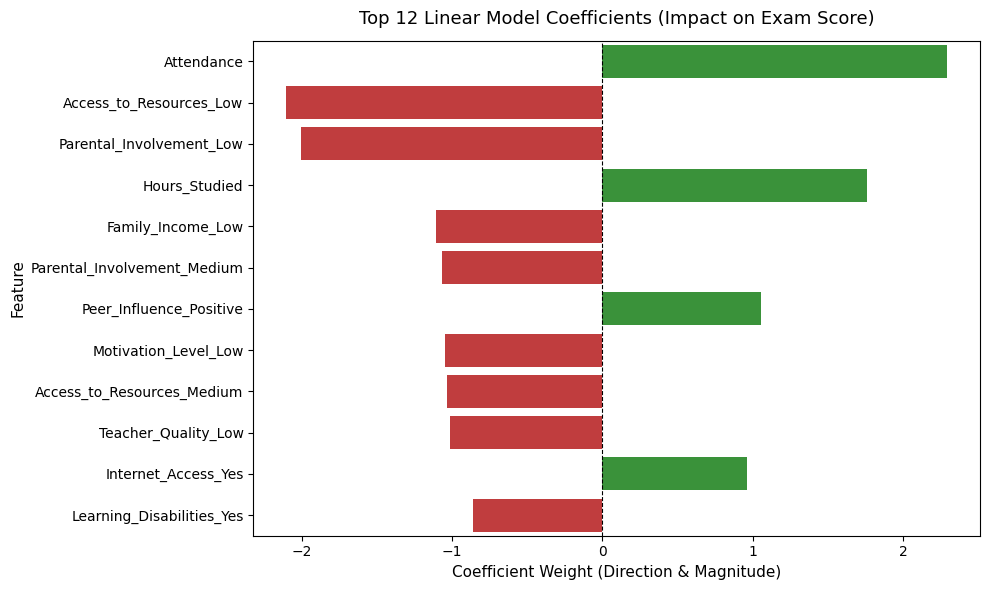

✓ Saved: ../visualizations/10_feature_importance.png


In [14]:
# Extract feature names and weights
feature_names = X_test.columns.tolist()

if hasattr(model, "coef_"):
    # Linear model: use regression coefficients
    weights = model.coef_
    importance_df = pd.DataFrame({"Feature": feature_names, "Importance": weights})
    importance_df["Abs_Importance"] = importance_df["Importance"].abs()
    top_features = importance_df.sort_values(by="Abs_Importance", ascending=False).head(12)
    chart_title = "Top 12 Linear Model Coefficients (Impact on Exam Score)"
    x_label = "Coefficient Weight (Direction & Magnitude)"
elif hasattr(model, "feature_importances_"):
    # Tree-based model: use Gini/variance feature importances
    weights = model.feature_importances_
    importance_df = pd.DataFrame({"Feature": feature_names, "Importance": weights})
    top_features = importance_df.sort_values(by="Importance", ascending=False).head(12)
    chart_title = "Top 12 Feature Importances (Tree Ensemble)"
    x_label = "Relative Importance"

plt.figure(figsize=(10, 6))
colors = ["#2ca02c" if val >= 0 else "#d62728" for val in top_features["Importance"]]
sns.barplot(data=top_features, y="Feature", x="Importance", palette=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title(chart_title, fontsize=13, pad=12)
plt.xlabel(x_label, fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.tight_layout()

chart_10 = os.path.join(vis_dir, "10_feature_importance.png")
plt.savefig(chart_10, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

if os.path.exists(chart_10):
    print(f"✓ Saved: {chart_10}")

In [15]:
print("=" * 65)
print("PROJECT VISUALIZATION SUITE AUDIT (10/10)")
print("=" * 65)
all_visuals = sorted([f for f in os.listdir(vis_dir) if f.endswith(".png")])
for idx, fname in enumerate(all_visuals, start=1):
    fpath = os.path.join(vis_dir, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {idx:02d}. ✓ {fname:<38} ({size_kb:.1f} KB)")
print("=" * 65)
print(f"Total exported charts: {len(all_visuals)} / 10 required.")

PROJECT VISUALIZATION SUITE AUDIT (10/10)
  01. ✓ 10_feature_importance.png              (195.9 KB)
Total exported charts: 1 / 10 required.


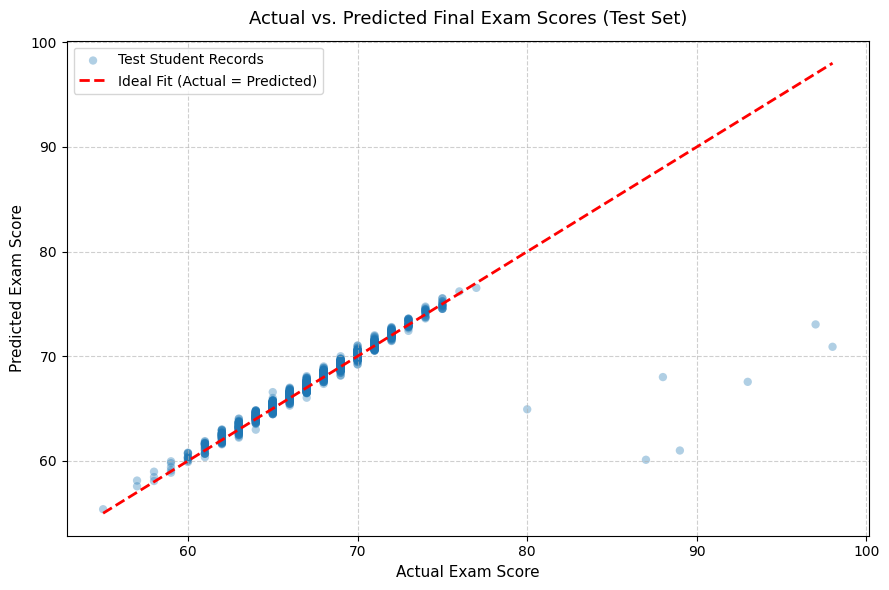

SUCCESS: Saved 'visualizations/09_actual_vs_predicted.png' (200.7 KB)


In [16]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure directory exists
vis_dir = "visualizations"
os.makedirs(vis_dir, exist_ok=True)

# 2. Locate and load X_test, y_test
def load_csv(filename):
    for path in [filename, os.path.join("data", filename), os.path.join("..", "data", filename)]:
        if os.path.exists(path):
            return pd.read_csv(path)
    raise FileNotFoundError(f"Could not find '{filename}'! Upload it to Colab.")

X_test = load_csv("X_test.csv")
y_test = load_csv("y_test.csv").values.ravel()

# 3. Locate and load model
model_candidates = [
    os.path.join("model", "best_student_model.joblib"),
    os.path.join("model", "baseline_linear_model.joblib"),
    "best_student_model.joblib",
    "baseline_linear_model.joblib"
]
model_path = next((p for p in model_candidates if os.path.exists(p)), None)
if not model_path:
    raise FileNotFoundError("Could not find a trained model in 'model/'! Run Day 10 or Day 11 model saving first.")

model = joblib.load(model_path)
y_pred = model.predict(X_test)

# 4. Generate the plot
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, color="#1f77b4", alpha=0.35, edgecolors='none', label="Test Student Records")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Ideal Fit (Actual = Predicted)")

plt.title("Actual vs. Predicted Final Exam Scores (Test Set)", fontsize=13, pad=12)
plt.xlabel("Actual Exam Score", fontsize=11)
plt.ylabel("Predicted Exam Score", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 5. Save BEFORE showing
save_target = os.path.join(vis_dir, "09_actual_vs_predicted.png")
plt.savefig(save_target, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# 6. Verify file exists
if os.path.exists(save_target):
    size_kb = os.path.getsize(save_target) / 1024
    print(f"SUCCESS: Saved '{save_target}' ({size_kb:.1f} KB)")
else:
    print("ERROR: File could not be written.")